# End-to-End Project: House Prices

This project uses machine learning to predict house prices using a census dataset.

**Eight steps for an ML project:**

1. Frame the problem and look at the big picture
    - How will your solution be used? What is the current solution? How would you do it without ML?
    - How is success measured? What is minimum performance needed to meet objective? 
    - Frame the problem in ML terms (supervised, regression, etc.)
    - List all assumptions about the data, the solution, the needs, etc.
2. Get data
    - What data do you need and how much?
    - Get the data, document where it came from, check access obligations, protect the raw data
    - Sample a test set and put it aside
3. Explore data
    - Record exploration in a notebook
    - Take a sample if it's too big to explore easily
    - Note EACH attribute and their characteristics: 
        - Type (categorical, float, bounded, structured, etc.)
        - % missing values
        - Noisiness and type (stochastic, outliers, rounding errors, etc.)
        - Distribution (normal, uniform, logarithmic)
    - If supervised learning, point out target
    - Visualize
    - Check for correlations between attributes
    - How would you solve the problem manually, without ML?
    - Check for any useful transformations you could apply
    - Check if there is any additional data that would be useful
4. Prepare data
    - Write functions for ALL transformations (these are like hyperparameters)
    - Clean up (fix/remove outliers and missing values)
    - Might need to do feature selection (drop useless ones)
    - Might need to do feature engineering (make some discrete, transform, combine, scale)
5. Shortlist promising models
    - Maybe try multiple models, using sample of data to be faster (if appropriate)
    - Train many model types (linear, SVM, etc.) using standard parameters
    - Compare performance using N-fold cross-validation (compute mean and std dev of performance measures on the N folds)
    - Analyze most significant variables for each algorithm
    - Analyze types of errors each model makes (what data would a human have used to avoid these errors?)
    - Do some quck feature selection/engineering
    - Do 1-2 more iterations of previous steps
    - Shortlist top 3-5 models (prefer ones that make different types of errors)
6. Fine-tune the system
    - Use as much data as you can for this
    - Fine-tune hyperparameters (including transformations) using cross-validation
    - When fine-tuning hyperparameters, preferrandom search over grid serach if many. If training is long, try Bayesian approach
    - Try ensemble methods (combining best models together)
    - Then measure your best final model on the test set and estimate generalization error
7. Present the solution
    - Big picture, why your solution achieves business objective, interesting things you learned, nice visualizations
8. Launch
    - Write unit tests
    - Write monitoring code that triggers you when model performance drops (e.g. 'rots' over time) or input data is poor
    - Re-train on regular basis on fresh data (try to automate this)

# 1. Frame the problem

We want to predict median house prices for each district. This info will be fed into another ML tool that tells the company whether to invest in that area or not.

# 2. Get the data

In [22]:
from pathlib import Path
import pandas as pd
import numpy as np
import tarfile
import urllib.request
import matplotlib.pyplot as plt

Define function to get data and get the data.

In [10]:
def load_housing_data():
    '''Download (if needed) and extract tarball to read CSV and return DataFrame'''
    tar_path = Path('datasets/housing.tgz')
    if not tar_path.is_file():
        # Make datasets folder if it doesn't exist
        Path('datasets').mkdir(parents=True, exist_ok=True)
        url = 'https://github.com/ageron/data/raw/main/housing.tgz'
        urllib.request.urlretrieve(url, tar_path)

    with tarfile.open(tar_path) as housing_tar:
        housing_tar.extractall(path='datasets')

    return pd.read_csv('datasets/housing/housing.csv')

housing = load_housing_data()

/var/folders/zx/67h80n3x46j6pxs1gd9vysx00000gn/T/ipykernel_51747/3708220785.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tar.extractall(path='datasets')


# 3. Explore the data

In [11]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [12]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [13]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


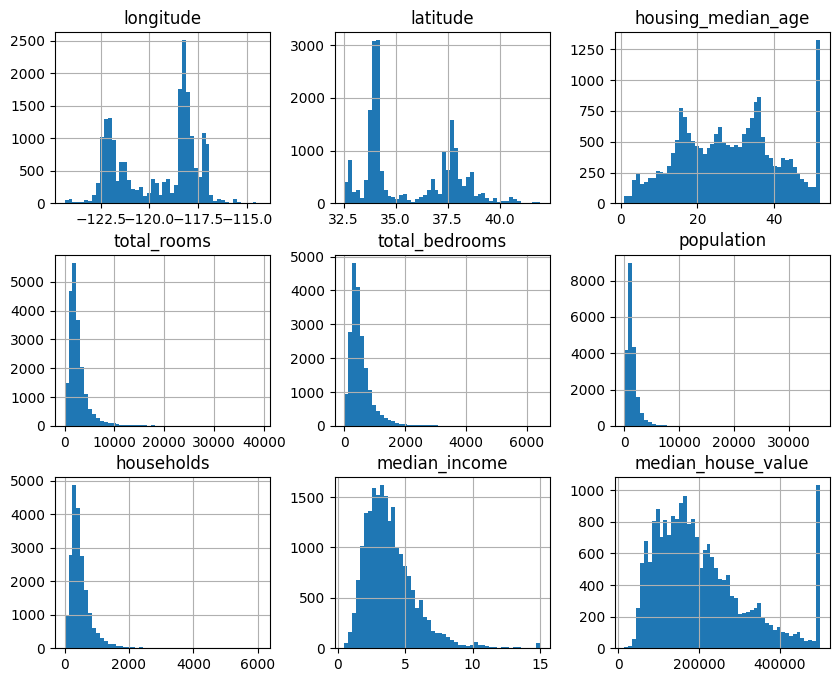

In [21]:
# Lets take a look at each attribute visually

housing.hist(bins = 50,
             figsize = (10, 8))
plt.show()

**Now, create the test set.** 